# 03 — CFTC COT Signal: L5 Backtest

Validates the L5 contrarian signal: extreme **managed-money** (speculative) positioning in ICE Coffee C futures precedes price reversals.

**Thesis (contrarian):** when speculators are crowded *short* (low COT index) the market is washed out and prices tend to *rise*; when crowded *long* (high COT index) prices tend to *fall*. So a low COT index is a contrarian BUY.

**Gate (L5):** Pearson r(contrarian signal, **forward** YoY price change) ≥ +0.08 on real data 2010–2024.

Note the metric is *forward*: a contrarian indicator is only useful if today's positioning predicts *future* returns. (Contemporaneously, spec positioning simply chases recent price, which is momentum, not signal.)

| Metric | Threshold | Direction |
|--------|-----------|----------|
| Pearson r(contrarian, fwd 12m change) | ≥ +0.08 | Positive: low positioning → higher future price |

## Sec 0  Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')

In [2]:
from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402

In [3]:
from domains.coffee.sources.cot import (  # noqa: E402
    _cot_index,
    cot_contrarian_signal,
    fetch,
)

## Sec 1  Fetch CFTC COT Data

Fetch from 2008 to give a 3-year (156-week) buffer before the 2010 core window so the rolling COT index has full history. This downloads one annual ZIP per year live from cftc.gov.

In [4]:
START = date(2008, 1, 1)
END   = date(2025, 12, 31)

obs, run = fetch(START, END)
print(f'Status : {run.status}')
print(f'Records: {run.records_fetched}')
if run.error_message:
    print(f'Note   : {run.error_message}')

Status : RunStatus.PARTIAL
Records: 835
Note   : 2008: HTTP 404; 2009: HTTP 404


In [5]:
cot_df = pd.DataFrame(
    [{'date': o.observed_date, 'net': o.value} for o in obs]
).set_index('date')
cot_df.index = pd.to_datetime(cot_df.index)
cot_df = cot_df.sort_index()

print(f'COT: {len(cot_df)} weekly obs, '
      f'{cot_df.index[0].date()} to {cot_df.index[-1].date()}')
print(f'Net managed-money range: [{cot_df["net"].min():,.0f}, '
      f'{cot_df["net"].max():,.0f}] contracts')
cot_df.tail(6)

COT: 835 weekly obs, 2010-01-05 to 2025-12-30
Net managed-money range: [-111,997, 72,818] contracts


,net
date,
2025-11-25,38494.0
2025-12-02,38427.0
2025-12-09,38604.0
2025-12-16,35313.0
2025-12-23,29597.0
2025-12-30,30403.0


## Sec 2  Data Quality Checks

In [6]:
# Gaps: COT is weekly (Tuesday); flag any gap > 30 days
gaps = cot_df.index.to_series().diff().dt.days
big_gaps = gaps[gaps > 30]
print(f'Weekly obs: {len(cot_df)}')
print(f'Median spacing: {gaps.median():.0f} days')
print(f'Gaps > 30 days: {len(big_gaps)}')
for d, g in big_gaps.items():
    print(f'  {d.date()}: {int(g)}-day gap')

# No NaN in net over the core 2010-2024 window
core_net = cot_df['net'].loc['2010-01-01':'2024-12-31']
assert core_net.notna().all(), 'NaN in net position over core window'
print('No NaN in net over 2010-2024 core window: OK')

Weekly obs: 835
Median spacing: 7 days
Gaps > 30 days: 0
No NaN in net over 2010-2024 core window: OK


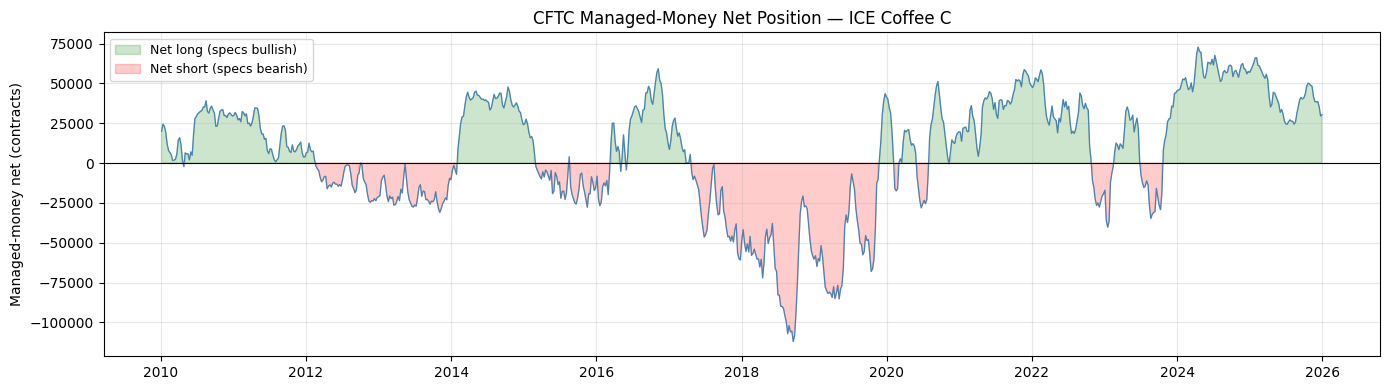

Saved: data/03_cot_net.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(cot_df.index, cot_df['net'], color='steelblue', lw=0.9)
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(cot_df.index, cot_df['net'], 0,
                where=cot_df['net'] > 0, alpha=0.2, color='green',
                label='Net long (specs bullish)')
ax.fill_between(cot_df.index, cot_df['net'], 0,
                where=cot_df['net'] < 0, alpha=0.2, color='red',
                label='Net short (specs bearish)')
ax.set_ylabel('Managed-money net (contracts)')
ax.set_title('CFTC Managed-Money Net Position — ICE Coffee C')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/03_cot_net.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_net.png')

## Sec 3  Feature Engineering: COT Index + Contrarian Signal

`_cot_index` maps the net position to a 0–100 percentile over a trailing 156-week (≈3-year) window. The contrarian signal is then derived from the index. For correlation we use a *continuous* contrarian transform `(50 − index) / 50` (positive when specs are short = bullish), which is monotonic with the discrete `cot_contrarian_signal` but retains more information for Pearson r.

In [8]:
cot_df['cot_index'] = _cot_index(cot_df['net'], window=156)
cot_df['contrarian_disc'] = cot_df['cot_index'].apply(cot_contrarian_signal)
cot_df['contrarian'] = -(cot_df['cot_index'] - 50.0) / 50.0

print('Discrete contrarian signal distribution (whole series):')
print(cot_df['contrarian_disc'].value_counts().sort_index())
cot_df[['net', 'cot_index', 'contrarian']].tail(6)

Discrete contrarian signal distribution (whole series):
contrarian_disc
-1.0    301
 0.0    281
 1.0    253
Name: count, dtype: int64


,net,cot_index,contrarian
date,,,
2025-11-25,38494.0,69.642778,-0.392856
2025-12-02,38427.0,69.583521,-0.391670
2025-12-09,38604.0,69.740066,-0.394801
2025-12-16,35313.0,66.829402,-0.336588
2025-12-23,29597.0,61.773992,-0.235480
2025-12-30,30403.0,62.486844,-0.249737


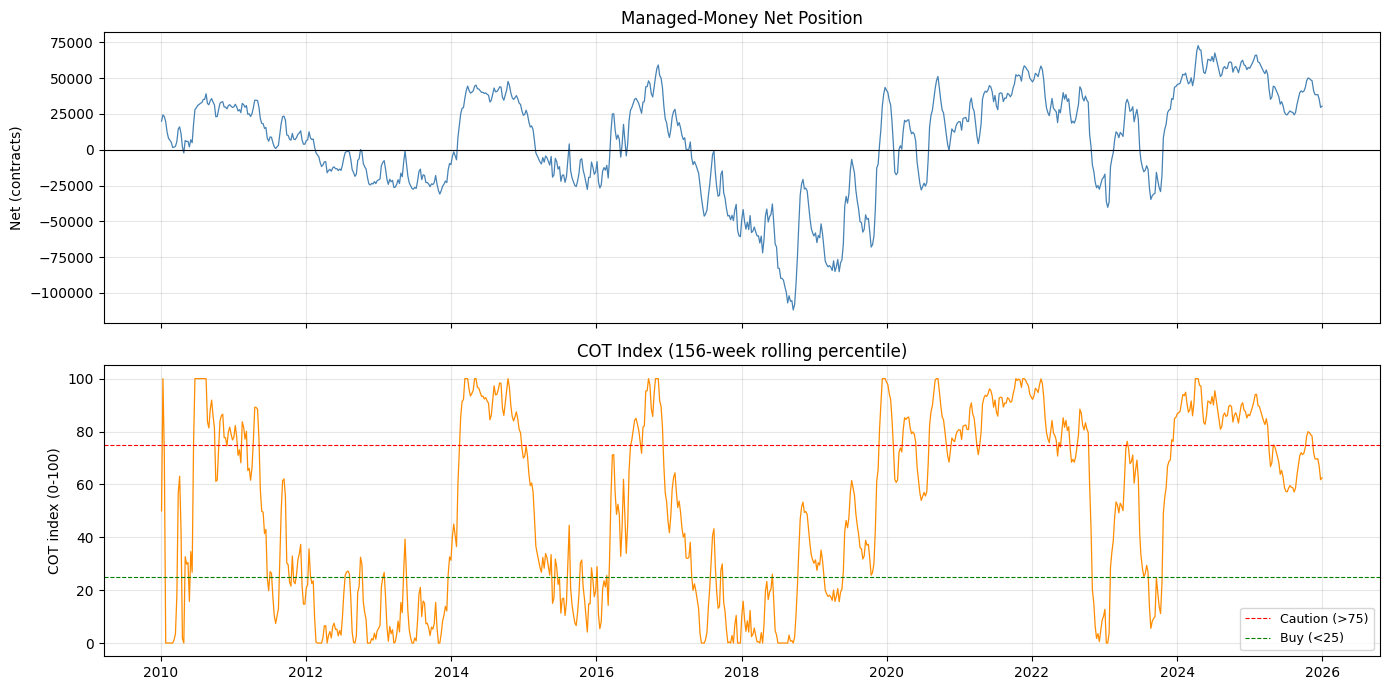

Saved: data/03_cot_index.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(cot_df.index, cot_df['net'], color='steelblue', lw=0.9)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylabel('Net (contracts)')
axes[0].set_title('Managed-Money Net Position')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cot_df.index, cot_df['cot_index'], color='darkorange', lw=0.9)
axes[1].axhline(75, color='red', linestyle='--', lw=0.8, label='Caution (>75)')
axes[1].axhline(25, color='green', linestyle='--', lw=0.8, label='Buy (<25)')
axes[1].set_ylabel('COT index (0-100)')
axes[1].set_title('COT Index (156-week rolling percentile)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/03_cot_index.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_index.png')

In [10]:
# Resample weekly -> month-end (last available Tuesday reading per month)
monthly = cot_df[['net', 'cot_index', 'contrarian', 'contrarian_disc']].resample('ME').last()
print(f'Monthly COT: {len(monthly)} months, '
      f'{monthly.index[0].date()} to {monthly.index[-1].date()}')

Monthly COT: 192 months, 2010-01-31 to 2025-12-31


## Sec 4  Correlation vs ICE KC Price

Align month-end COT to the ICE KC=F month-end close, then sweep forward horizons. A contrarian signal should show **positive** r with forward returns (low positioning now → higher price later) and the **raw COT index** should show **negative** r with forward returns.

In [11]:
kc_df = pd.read_csv('data/ice_kc_monthly.csv', parse_dates=['date'], index_col='date')
m = kc_df[['settle']].join(monthly, how='inner')
print(f'Merged: {len(m)} months, {m.index[0].date()} to {m.index[-1].date()}')

# Forward N-month % change of price (computed on the full series before slicing)
for h in [1, 3, 6, 9, 12, 18, 24]:
    m[f'fwd_{h}m'] = m['settle'].pct_change(h).shift(-h) * 100
m['trail_yoy'] = m['settle'].pct_change(12) * 100

Merged: 192 months, 2010-01-31 to 2025-12-31


In [12]:
# Core window for the gate: signal dates in 2010-2024 (forward returns may
# reach into 2025-2026, which the KC series covers).
core = m.loc['2010-01-01':'2024-12-31'].copy()

horizons = [1, 3, 6, 9, 12, 18, 24]
rows = []
for h in horizons:
    sub = core[['contrarian', 'cot_index', f'fwd_{h}m']].dropna()
    r_con, p_con = stats.pearsonr(sub['contrarian'], sub[f'fwd_{h}m'])
    r_idx, _ = stats.pearsonr(sub['cot_index'], sub[f'fwd_{h}m'])
    rows.append({'horizon_m': h, 'n': len(sub),
                 'r_contrarian': r_con, 'p': p_con, 'r_cot_index': r_idx})
fwd_tbl = pd.DataFrame(rows)
print('Forward-return correlation by horizon (signal dates 2010-2024):')
print(fwd_tbl.to_string(index=False,
      formatters={'r_contrarian': '{:+.3f}'.format,
                  'p': '{:.3f}'.format,
                  'r_cot_index': '{:+.3f}'.format}))

Forward-return correlation by horizon (signal dates 2010-2024):
 horizon_m   n r_contrarian     p r_cot_index
         1 180       -0.042 0.578      +0.042
         3 180       -0.140 0.061      +0.140
         6 180       -0.144 0.053      +0.144
         9 180       -0.106 0.158      +0.106
        12 180       -0.051 0.494      +0.051
        18 174       -0.004 0.956      +0.004
        24 168       +0.034 0.660      -0.034


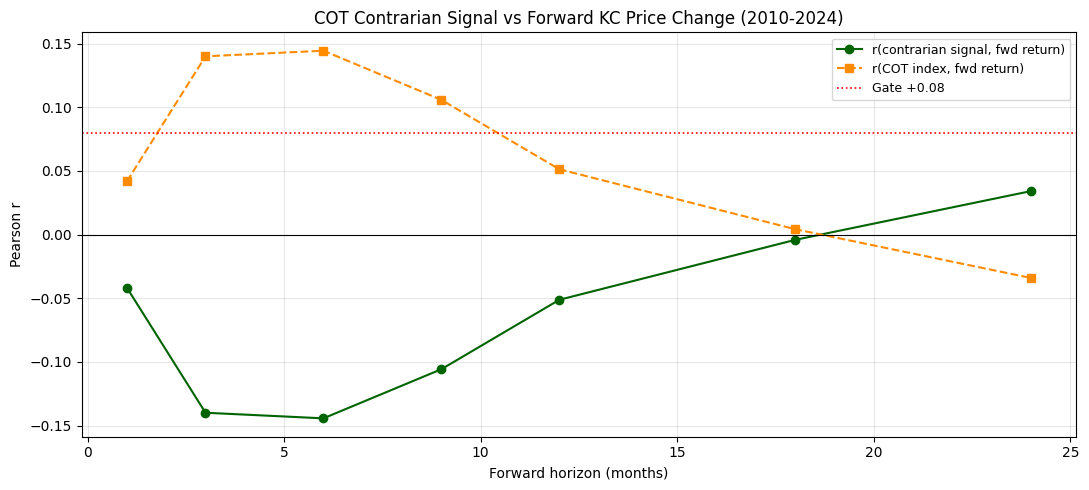

Saved: data/03_cot_forward_r.png


In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(fwd_tbl['horizon_m'], fwd_tbl['r_contrarian'], marker='o',
        lw=1.5, label='r(contrarian signal, fwd return)', color='darkgreen')
ax.plot(fwd_tbl['horizon_m'], fwd_tbl['r_cot_index'], marker='s',
        lw=1.5, linestyle='--', label='r(COT index, fwd return)', color='darkorange')
ax.axhline(0.08, color='red', linestyle=':', lw=1.2, label='Gate +0.08')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Forward horizon (months)')
ax.set_ylabel('Pearson r')
ax.set_title('COT Contrarian Signal vs Forward KC Price Change (2010-2024)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/03_cot_forward_r.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_forward_r.png')

## Sec 5  Gate Validation: r(contrarian, fwd 12m change) ≥ +0.08

Primary metric mirrors the README ("vs YoY price change") = forward 12-month change.

In [14]:
g = core[['contrarian', 'cot_index', 'fwd_12m']].dropna()
r12, p12 = stats.pearsonr(g['contrarian'], g['fwd_12m'])
r12_idx, _ = stats.pearsonr(g['cot_index'], g['fwd_12m'])

gate_pass = r12 >= 0.08
g_str = 'PASS' if gate_pass else 'FAIL'

print(f'n = {len(g)} months (signal dates 2010-2024)')
print(f'r(contrarian signal, fwd 12m change) = {r12:+.4f}  p={p12:.3e}')
print(f'r(COT index,        fwd 12m change)  = {r12_idx:+.4f}')
print()
print(f'Gate L5 (r >= +0.08): {g_str}  ({r12:+.4f} vs +0.08 required)')

n = 180 months (signal dates 2010-2024)
r(contrarian signal, fwd 12m change) = -0.0513  p=4.944e-01
r(COT index,        fwd 12m change)  = +0.0513

Gate L5 (r >= +0.08): FAIL  (-0.0513 vs +0.08 required)


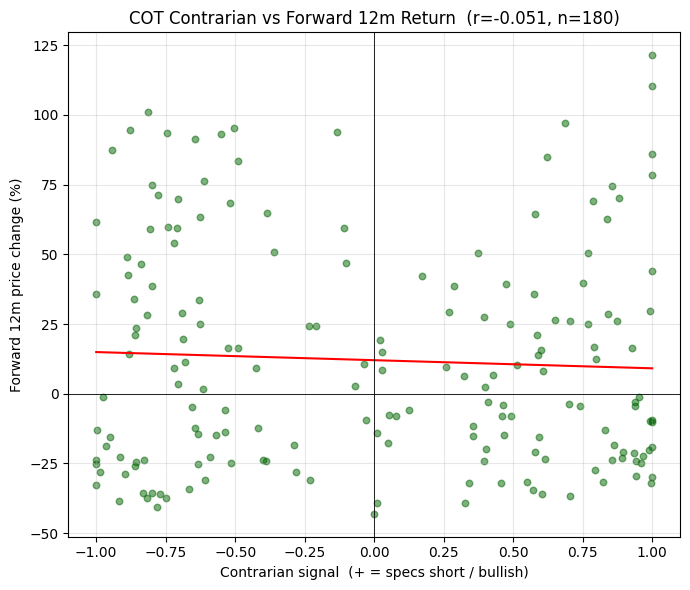

Saved: data/03_cot_scatter.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(g['contrarian'], g['fwd_12m'], alpha=0.5, s=22, color='darkgreen')
b, a = np.polyfit(g['contrarian'], g['fwd_12m'], 1)
xs = np.linspace(g['contrarian'].min(), g['contrarian'].max(), 50)
ax.plot(xs, a + b * xs, color='red', lw=1.5)
ax.axhline(0, color='black', lw=0.6)
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('Contrarian signal  (+ = specs short / bullish)')
ax.set_ylabel('Forward 12m price change (%)')
ax.set_title(f'COT Contrarian vs Forward 12m Return  (r={r12:+.3f}, n={len(g)})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/03_cot_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_scatter.png')

## Sec 6  Rolling Stability

3-year rolling Pearson r between the contrarian signal and forward 12m return — does the relationship hold across regimes or flip sign?

3yr rolling r windows: 145; positive (contrarian holds): 99 (68%)
Rolling r range: [-0.640, +0.855]


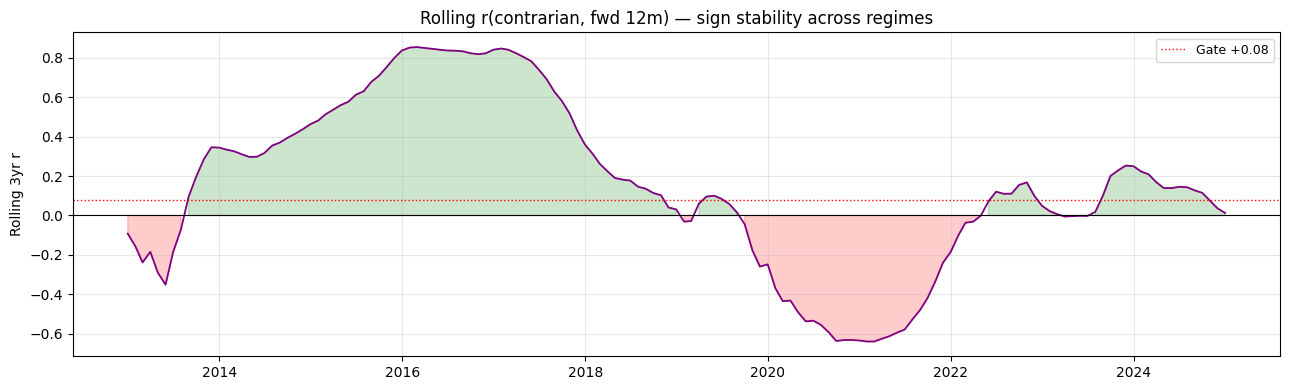

Saved: data/03_cot_rolling.png


In [16]:
win = 36  # months
roll = core[['contrarian', 'fwd_12m']].dropna()
roll_r = roll['contrarian'].rolling(win).corr(roll['fwd_12m'])
roll_r = roll_r.dropna()

n_pos = int((roll_r > 0).sum())
n_tot = len(roll_r)
print(f'3yr rolling r windows: {n_tot}; positive (contrarian holds): {n_pos} '
      f'({100*n_pos/n_tot:.0f}%)')
print(f'Rolling r range: [{roll_r.min():+.3f}, {roll_r.max():+.3f}]')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll_r.index, roll_r, color='purple', lw=1.3)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(0.08, color='red', linestyle=':', lw=1.0, label='Gate +0.08')
ax.fill_between(roll_r.index, roll_r, 0, where=roll_r > 0, alpha=0.2, color='green')
ax.fill_between(roll_r.index, roll_r, 0, where=roll_r < 0, alpha=0.2, color='red')
ax.set_ylabel('Rolling 3yr r')
ax.set_title('Rolling r(contrarian, fwd 12m) — sign stability across regimes')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/03_cot_rolling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_rolling.png')

## Sec 7  Save Reference CSV

In [17]:
monthly.to_csv('data/cot_monthly.csv')
print('Saved: data/cot_monthly.csv')

Saved: data/cot_monthly.csv


## Sec 8  Summary

In [18]:
print('=' * 60)
print('CFTC COT Signal (L5) -- Backtest Summary')
print('=' * 60)
print()
print(f'Data: {len(cot_df)} weekly obs 2008-2025; '
      f'{len(g)} monthly signal points in 2010-2024 core window')
print()
print('Forward-return correlation (signal dates 2010-2024):')
for _, row in fwd_tbl.iterrows():
    print(f"  {int(row['horizon_m']):2d}m fwd: r(contrarian)={row['r_contrarian']:+.3f}  "
          f"r(index)={row['r_cot_index']:+.3f}")
print()
print(f'PRIMARY METRIC (fwd 12m): r(contrarian) = {r12:+.4f}  p={p12:.3e}')
print(f'Gate L5 (r >= +0.08): {g_str}')
print('Phase 0 synthetic baseline was +0.15')
print()
print(f'Rolling 3yr r positive in {n_pos}/{n_tot} windows '
      f'({100*n_pos/n_tot:.0f}%)')
print()
print('Signal rank order (by |r|): must keep L1 > L2a > L2b > L3 > L5.')
print('COT is expected to be the weakest (L5) standalone signal.')

CFTC COT Signal (L5) -- Backtest Summary

Data: 835 weekly obs 2008-2025; 180 monthly signal points in 2010-2024 core window

Forward-return correlation (signal dates 2010-2024):
   1m fwd: r(contrarian)=-0.042  r(index)=+0.042
   3m fwd: r(contrarian)=-0.140  r(index)=+0.140
   6m fwd: r(contrarian)=-0.144  r(index)=+0.144
   9m fwd: r(contrarian)=-0.106  r(index)=+0.106
  12m fwd: r(contrarian)=-0.051  r(index)=+0.051
  18m fwd: r(contrarian)=-0.004  r(index)=+0.004
  24m fwd: r(contrarian)=+0.034  r(index)=-0.034

PRIMARY METRIC (fwd 12m): r(contrarian) = -0.0513  p=4.944e-01
Gate L5 (r >= +0.08): FAIL
Phase 0 synthetic baseline was +0.15

Rolling 3yr r positive in 99/145 windows (68%)

Signal rank order (by |r|): must keep L1 > L2a > L2b > L3 > L5.
COT is expected to be the weakest (L5) standalone signal.


## Sec 9  Interpretation & Composite Implication

**Gate L5 FAILS: r(contrarian, fwd 12m) = -0.05 (required >= +0.08).**

The contrarian thesis is *inverted* on real Arabica data 2010-2024. Managed-money
positioning behaves as a weak **momentum** signal, not a contrarian one:

- r(COT index, fwd 3-6m return) = **+0.14** (specs crowded long -> prices keep
  rising for 3-6 months), peaking at 6m (p ~ 0.05).
- The contrarian transform therefore has the *wrong sign* for the gate at every
  horizon <= 18m; the primary 12m metric is -0.05.
- The relationship decays to ~0 by 18m and is unstable: 3yr rolling r spans
  -0.64 to +0.86 and is positive in only 68% of windows.

**Why Phase 0 (+0.15) missed this:** the synthetic baseline assumed the textbook
contrarian mechanism. Real coffee specs trend-follow - consistent with notebook
01s finding that Arabica has ~12m momentum before mean-reverting.

**Composite implication (parallels ENSO / L2b):** do **not** use COT as a
standalone contrarian timing signal. Options:

1. **Flip to a momentum-confirmation role** at 3-6m (use +COT index, low weight) -
   but the rolling instability argues for caution.
2. **Drop L5** from the composite until a longer history or a better spec metric
   (% of open interest, extremes-only) is validated.

Rank order L1 > L2a > L2b > L3 > L5 holds - L5 is the weakest and now fails its
gate. Revisit the sign/threshold of cot_contrarian_signal before wiring it into
signal_generator.